In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv(
    r"C:\Users\HEMANGI SOLANKI\Desktop\KS\sem-10\Brainybeam\BestSellerAnalytics\books.csv",
    engine='python',
    on_bad_lines='skip'
)

In [5]:
df.head()

,Book_ID,Title,Author,Language,Pages,Ratings,Reviews,Publication_Date,Genre,Price,Year,Genre_Weight
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,eng,6.481577,4.57,2.744407,2006-09-16,Romance,4653.072288,2006,800
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,eng,6.769642,4.49,2.746145,2004-09-01,Comedy,5033.007373,2004,700
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,eng,5.866468,4.42,2.277645,2003-11-01,Horror,5651.093900,2003,1500
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,eng,6.077642,4.56,2.751460,2004-05-01,Thriller,6105.698830,2004,600
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,eng,7.897668,4.78,2.453737,2004-09-13,Thriller,6232.327089,2004,600


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11117 entries, 0 to 11116
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Book_ID           11117 non-null  int64  
 1   Title             11117 non-null  object 
 2   Author            11117 non-null  object 
 3   Language          11117 non-null  object 
 4   Pages             11117 non-null  float64
 5   Ratings           11117 non-null  float64
 6   Reviews           11117 non-null  float64
 7   Publication_Date  11117 non-null  object 
 8   Genre             11117 non-null  object 
 9   Price             11117 non-null  float64
 10  Year              11117 non-null  int64  
 11  Genre_Weight      11117 non-null  int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 1.0+ MB


In [7]:
print(df.columns)

Index(['Book_ID', 'Title', 'Author', 'Language', 'Pages', 'Ratings', 'Reviews',
       'Publication_Date', 'Genre', 'Price', 'Year', 'Genre_Weight'],
      dtype='object')


In [8]:
genres = ['Romance','Thriller','Drama','Comedy','Fantasy','Horror']
df['Genre'] = np.random.choice(genres, size=len(df))
df['Reviews'] = np.log1p(df['Reviews'])
genre_price_map = {
    'Romance': 300,
    'Thriller': 600,
    'Drama': 450,
    'Fantasy': 900,
    'Horror': 500,
    'Comedy': 350
}

df['Price'] = (

    df['Genre'].map(genre_price_map)

    + (df['Ratings'] * 250)

    + (df['Reviews'] * 40)

    + (df['Pages'] * 2)

    + np.random.randint(-50, 50, size=len(df))
)
# Very low ratings reduce price

df.loc[df['Ratings'] < 2, 'Price'] *= 0.4

df.loc[df['Ratings'] < 1, 'Price'] *= 0.25
df['Price'] = df['Price'].clip(100, 3000)

In [9]:
df.describe()

,Book_ID,Pages,Ratings,Reviews,Price,Year,Genre_Weight
count,11117.000000,11117.000000,11117.000000,11117.000000,11117.000000,11117.000000,11117.000000
mean,21305.882073,5.545300,3.934118,1.068259,1551.877233,2000.172349,963.425385
std,13091.884902,0.935570,0.350412,0.174020,223.343842,8.246079,309.744692
min,1.000000,0.000000,0.000000,0.000000,100.000000,1900.000000,600.000000
25%,10270.000000,5.262690,3.770000,1.005164,1400.872304,1998.000000,700.000000
50%,20264.000000,5.703782,3.960000,1.108590,1515.832850,2003.000000,800.000000
75%,32103.000000,6.033086,4.140000,1.179589,1653.109425,2005.000000,1200.000000
max,45641.000000,8.791334,5.000000,1.333337,2215.890778,2020.000000,1500.000000


In [10]:
df.isnull().sum()

Book_ID             0
Title               0
Author              0
Language            0
Pages               0
Ratings             0
Reviews             0
Publication_Date    0
Genre               0
Price               0
Year                0
Genre_Weight        0
dtype: int64

In [11]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

In [12]:
df['Publication_Date'] = pd.to_datetime(df['Publication_Date'], errors='coerce')
df['Year'] = df['Publication_Date'].dt.year

df = df.dropna()

print(df.head())
print(df.columns)

   Book_ID                                              Title  \
0        1  Harry Potter and the Half-Blood Prince (Harry ...   
1        2  Harry Potter and the Order of the Phoenix (Har...   
2        4  Harry Potter and the Chamber of Secrets (Harry...   
3        5  Harry Potter and the Prisoner of Azkaban (Harr...   
4        8  Harry Potter Boxed Set  Books 1-5 (Harry Potte...   

                       Author Language     Pages  Ratings   Reviews  \
0  J.K. Rowling/Mary GrandPré      eng  6.481577     4.57  1.320263   
1  J.K. Rowling/Mary GrandPré      eng  6.769642     4.49  1.320727   
2                J.K. Rowling      eng  5.866468     4.42  1.187125   
3  J.K. Rowling/Mary GrandPré      eng  6.077642     4.56  1.322145   
4  J.K. Rowling/Mary GrandPré      eng  7.897668     4.78  1.239457   

  Publication_Date     Genre        Price  Year  Genre_Weight  
0       2006-09-16   Fantasy  2119.273689  2006           800  
1       2004-09-01   Fantasy  2109.868380  2004       

In [13]:
df.to_csv(r"C:\Users\HEMANGI SOLANKI\Desktop\KS\sem-10\Brainybeam\BestSellerAnalytics\processed_books.csv", index=False)

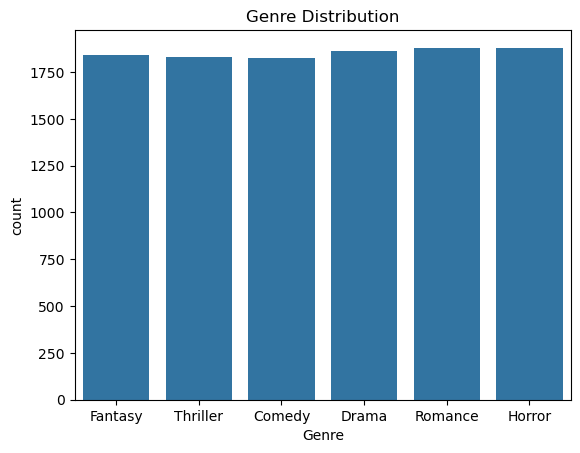

In [14]:
sns.countplot(x='Genre', data=df)
plt.title("Genre Distribution")
plt.show()

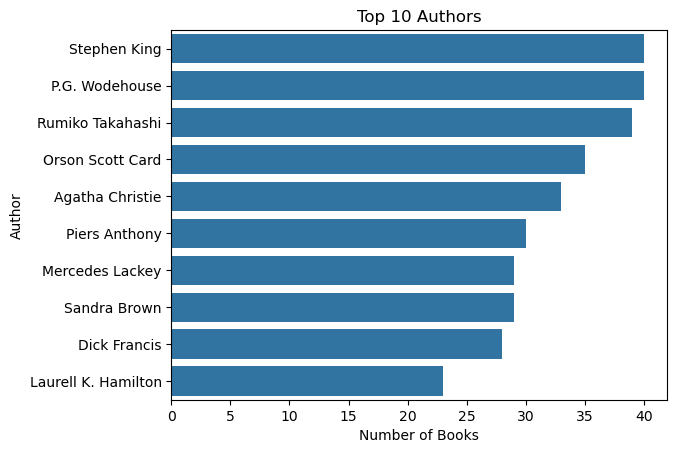

In [15]:
top_authors = df['Author'].value_counts().head(10)

sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title("Top 10 Authors")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.show()

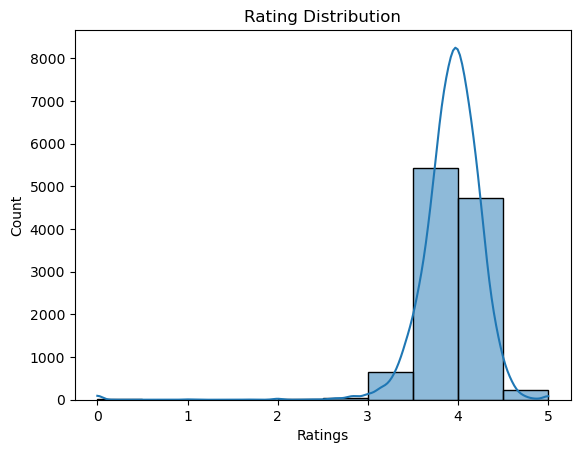

In [16]:
sns.histplot(df['Ratings'], bins=10, kde=True)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.show()

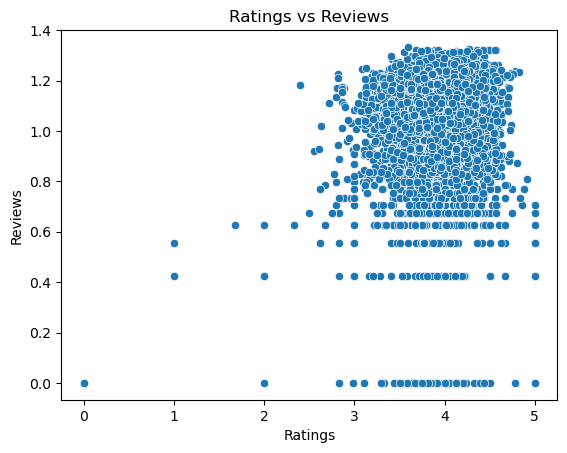

In [17]:
sns.scatterplot(x='Ratings', y='Reviews', data=df)
plt.title("Ratings vs Reviews")
plt.xlabel("Ratings")
plt.ylabel("Reviews")
plt.show()

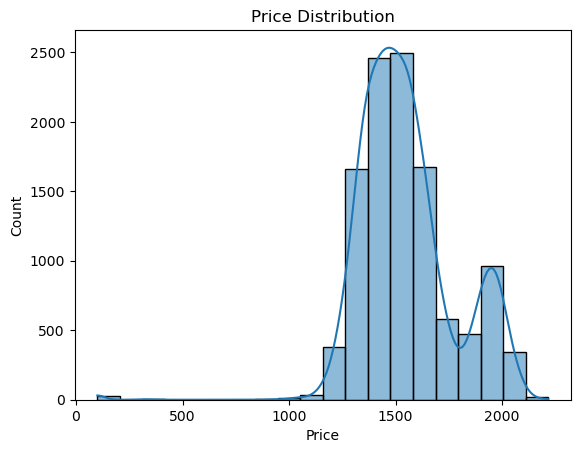

In [18]:
sns.histplot(df['Price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

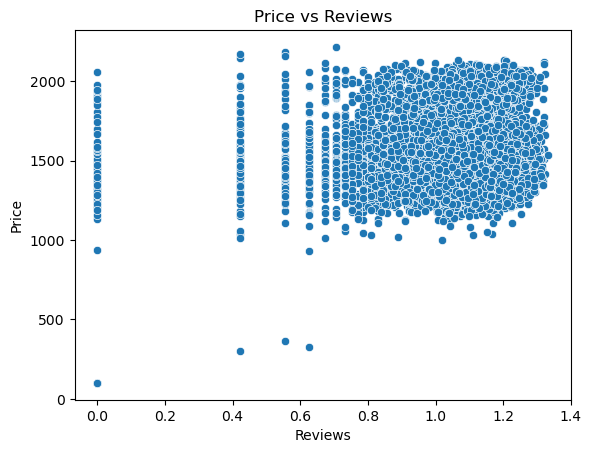

In [19]:
sns.scatterplot(x='Reviews', y='Price', data=df)
plt.title("Price vs Reviews")
plt.show()

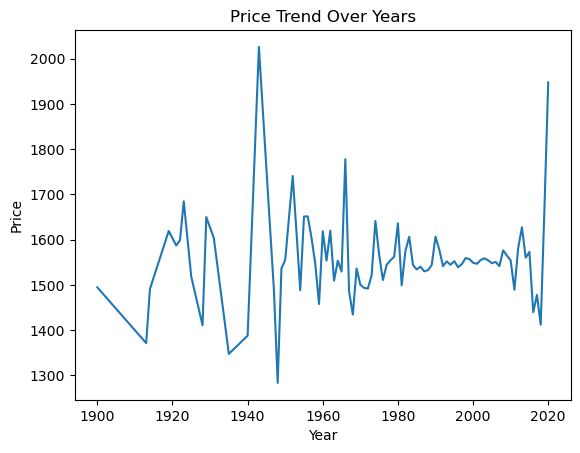

In [20]:
yearly_price = df.groupby('Year')['Price'].mean().reset_index()

sns.lineplot(x='Year', y='Price', data=yearly_price)
plt.title("Price Trend Over Years")
plt.show()

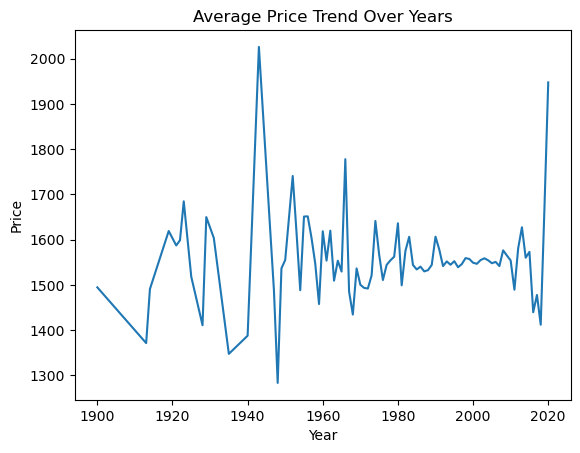

In [21]:
yearly_price = df.groupby('Year')['Price'].mean().reset_index()

sns.lineplot(x='Year', y='Price', data=yearly_price)
plt.title("Average Price Trend Over Years")
plt.show()

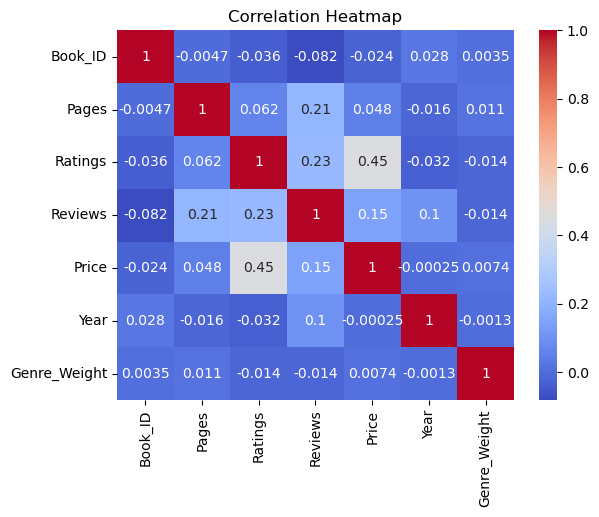

In [22]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

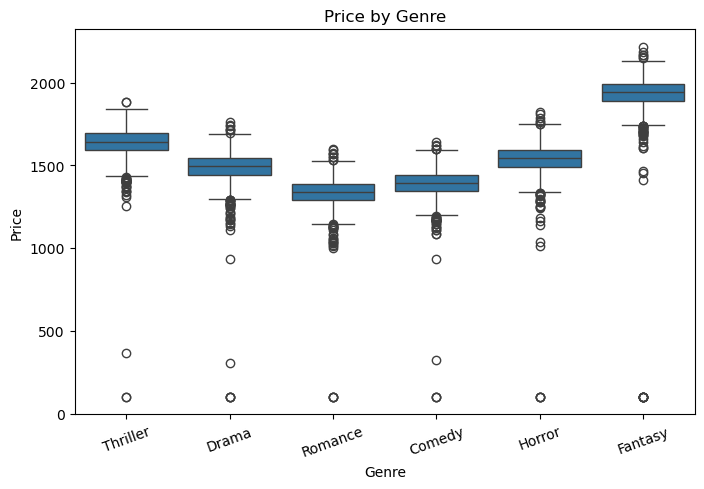

In [23]:
genre_order = [
    'Thriller',
    'Drama',
    'Romance',
    'Comedy',
    'Horror',
    'Fantasy'
]

plt.figure(figsize=(8,5))

sns.boxplot(x='Genre',y='Price',data=df,order=genre_order)
plt.title("Price by Genre")
plt.xlabel("Genre")
plt.ylabel("Price")
plt.xticks(rotation=20)
plt.show()

In [24]:
X = df[['Reviews', 'Ratings', 'Pages', 'Genre']]
y = df['Price']

# Encode Genre
X = pd.get_dummies(X, columns=['Genre'])

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred_lr = lr_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test[:5],
    "Predicted Price": y_pred_lr[:5]
})

print(comparison)

      Actual Price  Predicted Price
1864   1510.966282      1567.112864
3352   2035.149988      2040.729384
5094   1487.995587      1432.312062
8685   1230.313953      1262.756018
7539   1347.521944      1318.210123


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 26.955385068107738
RMSE: 34.93452386727127


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 26.81474521757549
RF RMSE: 31.90689488488295


In [30]:
models = ['Linear Regression', 'Random Forest']
mae_values = [mae, mae_rf]
rmse_values = [rmse, rmse_rf]

comparison = pd.DataFrame({
    'Model': models,
    'MAE': mae_values,
    'RMSE': rmse_values
})

print(comparison)

               Model        MAE       RMSE
0  Linear Regression  26.955385  34.934524
1      Random Forest  26.814745  31.906895


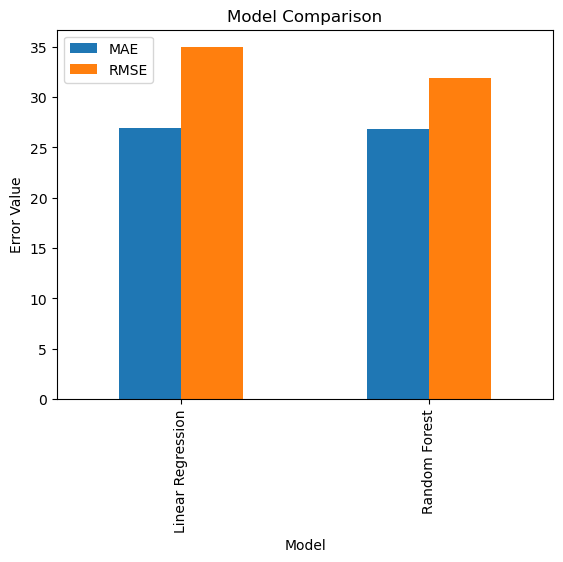

In [31]:
comparison.set_index('Model').plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Error Value")
plt.show()

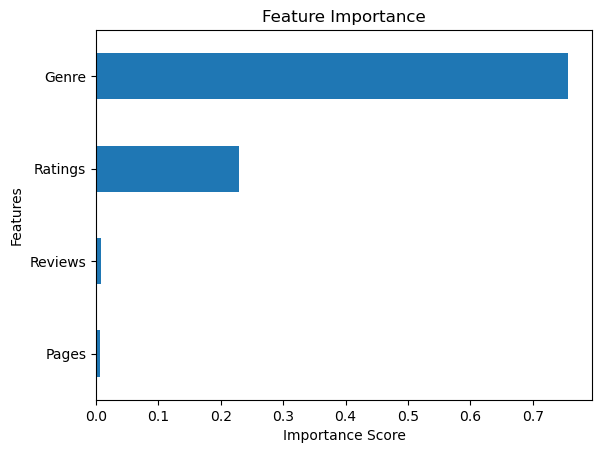

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
importance = rf_model.feature_importances_
genre_total = 0

for col, imp in zip(X.columns, importance):
    if "Genre_" in col:
        genre_total += imp

feature_map = {
    'Reviews': importance[list(X.columns).index('Reviews')],
    'Ratings': importance[list(X.columns).index('Ratings')],
    'Pages': importance[list(X.columns).index('Pages')],
    'Genre': genre_total
}


feat_imp = pd.Series(feature_map)

feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()